<a href="https://colab.research.google.com/github/vinicius-verona/dp-fair-intervention-benchmark/blob/dev/notebook/2026_Plot_All_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [1]:
!apt update && apt install texlive texlive-latex-extra texlive-fonts-recommended dvipng cm-super

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,643 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,302 kB]
Get:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease 

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

params = {'axes.titlesize':'18',
          'xtick.labelsize':'17',
          'ytick.labelsize':'17',
          'font.size':'17',
          'legend.fontsize':'medium',
          'lines.linewidth':'2.0',
          'font.weight':'normal',
          'lines.markersize':'8',
          'text.latex.preamble': r'\usepackage{amsfonts}',
          }
matplotlib.rcParams.update(params)
plt.rcParams["mathtext.fontset"] = "cm"
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

## Parameters

In [57]:
# =========================
# Configuration
# =========================
DP_SYNTHETIZER = 'aim'   # choose among: 'mst', 'aim'
INTERVENTION = 'all'     # choose among: 'all', 'PRE', 'IN', 'POST'

ML_MODELS = ['LR', 'RF', 'XGB']
UTILITY_METRICS = ['ACC']#, 'F1']
FAIRNESS_METRICS = ['MAD', 'EOD', 'SPD']

METRIC_LABELS = {
    'ACC': 'Accuracy (ACC)',
    'PREC': 'Precision (PREC)',
    'REC': 'Recall (REC)',
    'F1': 'F1-score (F1)',
    'MAD': 'Model Accuracy Difference (MAD)',
    'EOD': 'Equalized Opportunity Difference (EOD)',
    'SPD': 'Statistical Parity Difference (SPD)'
}

METHOD_ACRONYMS = {
    'reweigh-XGB': 'RW-XGB',
    'reweigh-RF': 'RW-RF',
    'reweigh-LR': 'RW-LR',
    'egr-XGB': 'EGR-XGB',
    'egr-RF': 'EGR-RF',
    'egr-LR': 'EGR-LR',
    'roc-XGB': 'ROC-XGB',
    'roc-RF': 'ROC-RF',
    'roc-LR': 'ROC-LR',
}

DATASETS = ['adult', 'folktables', 'compas', 'bod']
AVERAGE_BY_SEED = True

DP_ONLY_LABEL   = 'DP-ONLY'
FAIR_ONLY_LABEL = r'FAIR-ONLY ($\varepsilon=\infty$)'

# =========================
# Categorization
# =========================
intervention_map = {
    'PRE': ['reweigh'],
    'IN': ['egr'],
    'POST': ['roc']
}

label_intervention_model_map = {
    'PRE': ['reweigh-XGB', 'reweigh-RF', 'reweigh-LR'],
    'IN': ['egr-XGB', 'egr-RF', 'egr-LR'],
    'POST': ['roc-XGB', 'roc-RF', 'roc-LR']
}

method_to_cat = {m: cat for cat, ms in intervention_map.items() for m in ms}
method_to_cat[DP_ONLY_LABEL] = 'BASE'

if INTERVENTION.lower() == 'all':
    fair_methods = label_intervention_model_map['PRE'] + label_intervention_model_map['IN'] + label_intervention_model_map['POST']
elif INTERVENTION.upper() in label_intervention_model_map:
    fair_methods = label_intervention_model_map[INTERVENTION.upper()]
else:
    raise ValueError("INTERVENTION must be one of: 'all', 'PRE', 'IN', 'POST'.")

all_dp_only = [DP_ONLY_LABEL + '-XGB', DP_ONLY_LABEL + '-RF', DP_ONLY_LABEL + '-LR']
all_methods = fair_methods + all_dp_only

# =========================
# Visual mapping
# =========================
universe_methods = label_intervention_model_map['PRE'] + label_intervention_model_map['IN'] + label_intervention_model_map['POST'] + all_dp_only
colors_map = {m: plt.cm.tab20(i % 20) for i, m in enumerate(universe_methods)}

markers_map = {
    all_dp_only[0]: 'X',
    all_dp_only[1]: 'X',
    all_dp_only[2]: 'X',
    'reweigh-XGB': 'o',
    'reweigh-RF': 'o',
    'reweigh-LR': 'o',
    'egr-XGB': 's',
    'egr-RF': 's',
    'egr-LR': 's',
    'roc-XGB': '^',
    'roc-RF': '^',
    'roc-LR': '^',
}

# =========================
# Intervention stage mapping
# =========================
method_to_stage = {
    m: stage for stage, methods in intervention_map.items() for m in methods
}

STAGE_ORDER = ['PRE', 'IN', 'POST']

STAGE_COLORS = {
    'DP-ONLY': 'magenta',
    'PRE': '#1f77b4', #1f35b4 561fb4
    'IN': '#ff7f0e', #ff460e  a14040
    'POST': '#2ca02c', #7ba02c a0962c
}

STAGE_MARKERS = {
    'DP-ONLY': 'X',
    'PRE': 'o',
    'IN': 's',
    'POST': '^',
}

ML_STAGE_MARKERS = {
    'DP-ONLY-XGB': 'X',
    'DP-ONLY-RF': 'X',
    'DP-ONLY-LR': 'X',
    'PRE-XGB': 'o',
    'PRE-RF': 'o',
    'PRE-LR': 'o',
    'IN-XGB': 's',
    'IN-RF': 's',
    'IN-LR': 's',
    'POST-XGB': '^',
    'POST-RF': '^',
    'POST-LR': '^'
}


## Plotting

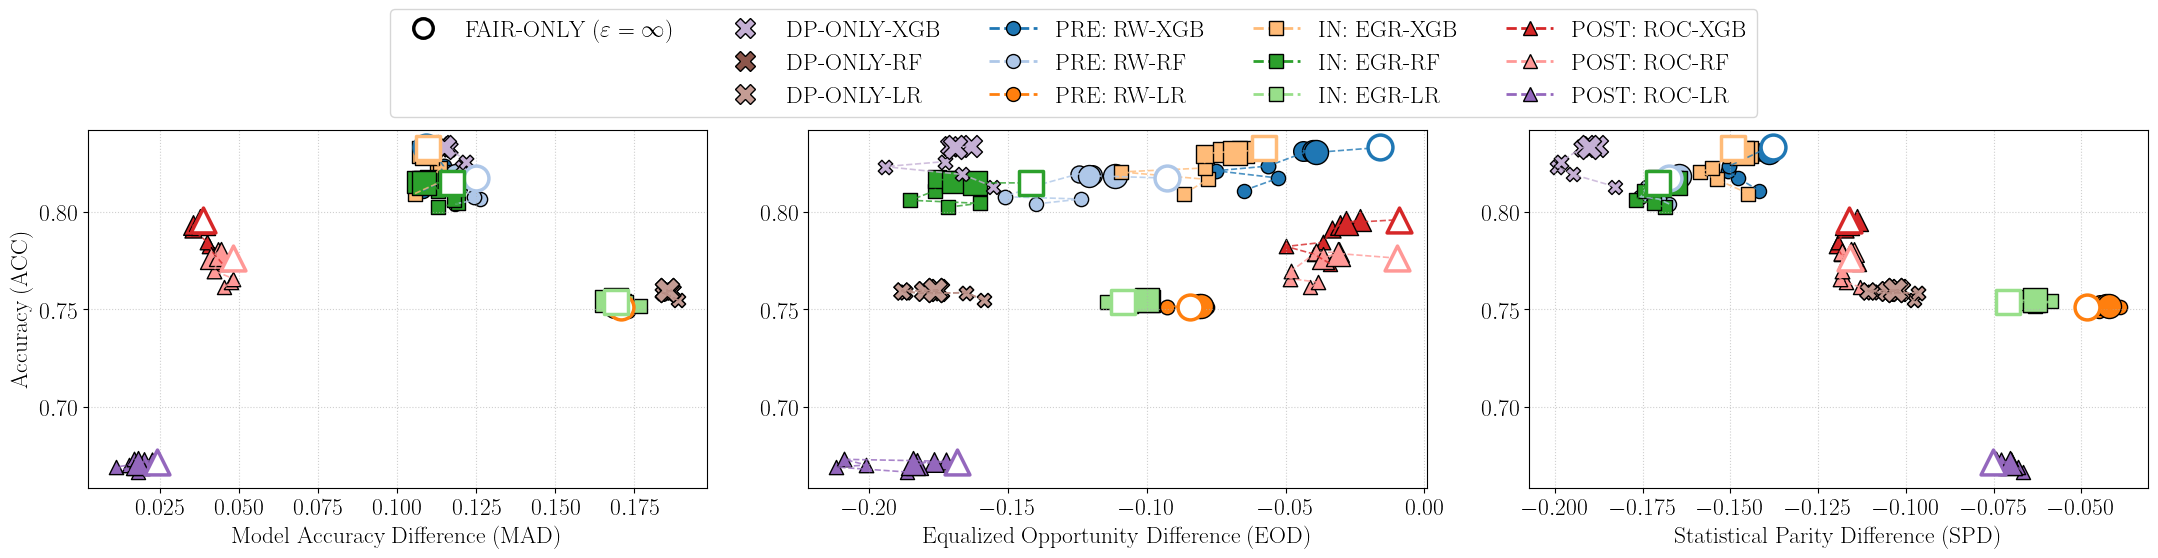

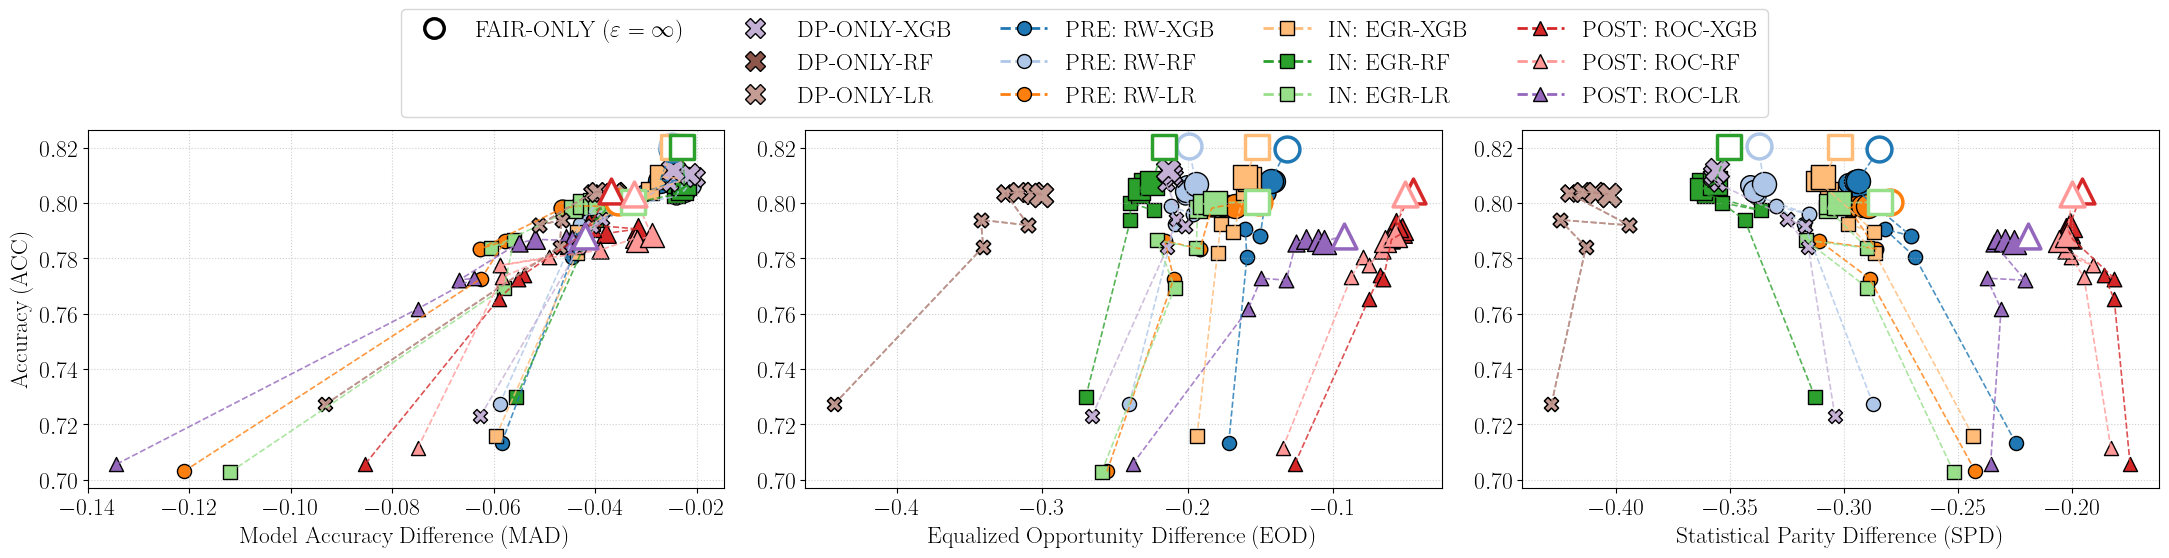

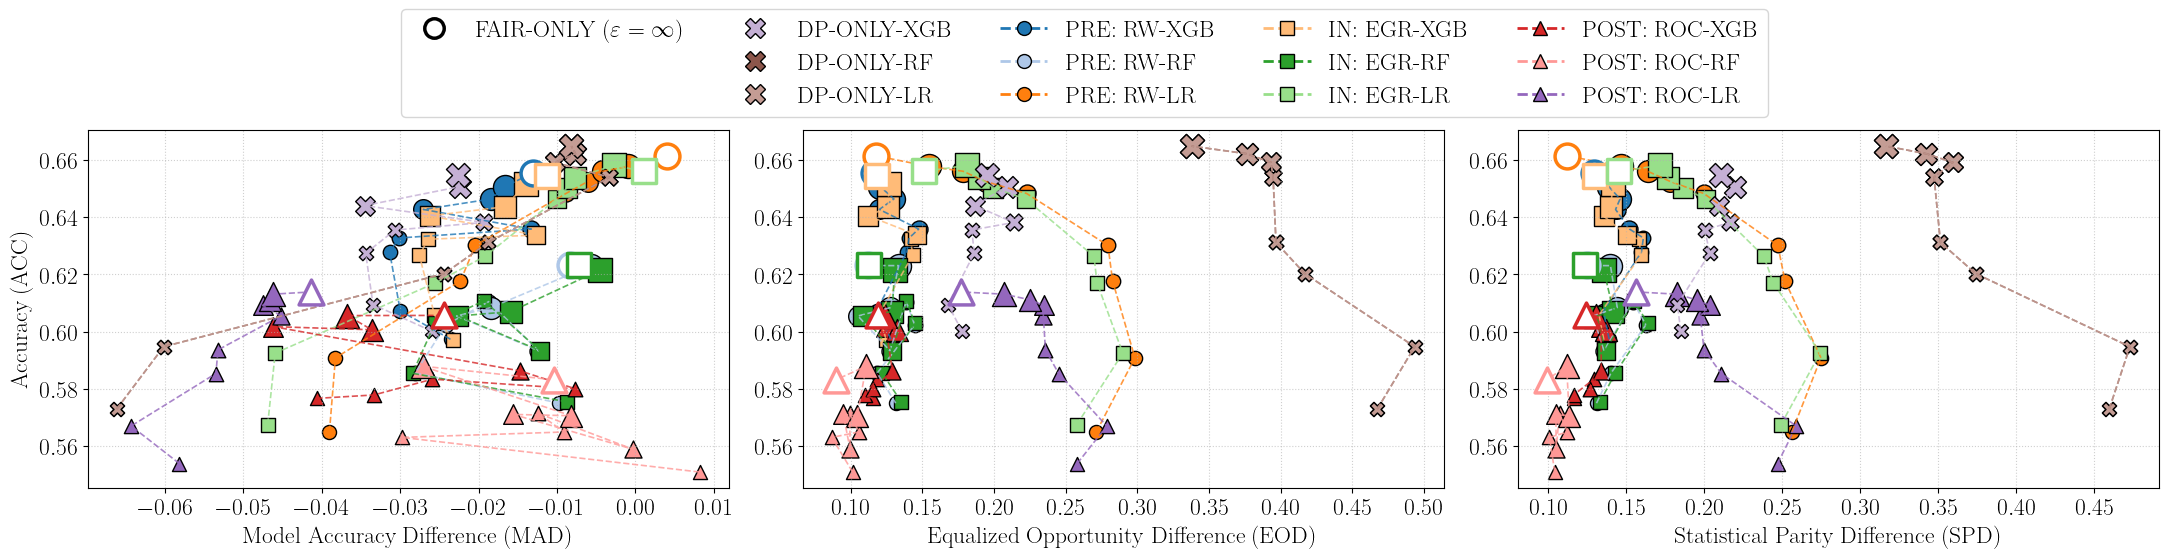

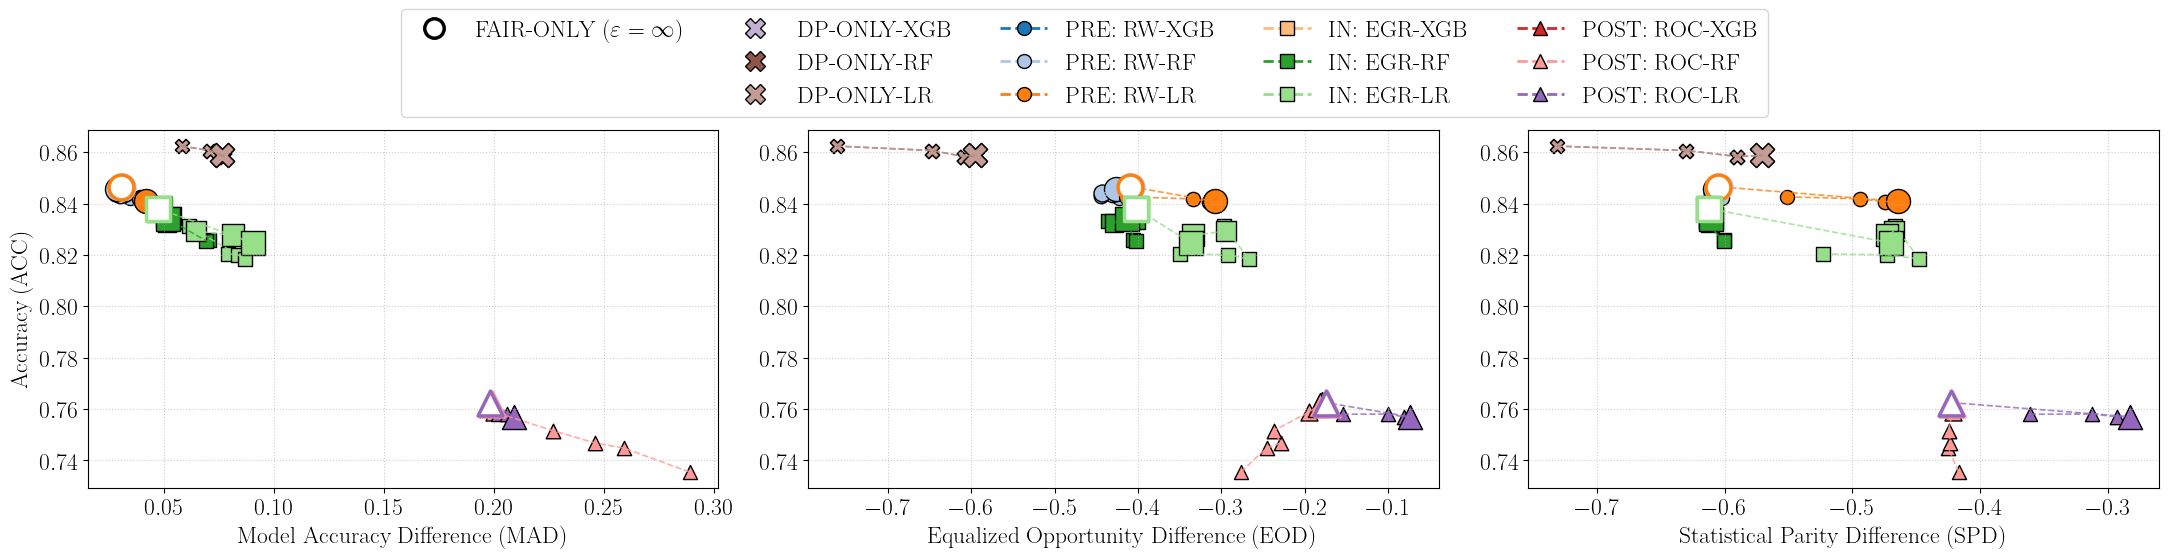

In [58]:
# =========================
# Processing and plotting
# =========================

for UTILITY_METRIC in UTILITY_METRICS:
    for COMBO in [1,2,3,4,5,6]:
        for dataset in DATASETS:
            if dataset != 'bod' and COMBO != 1:
                continue

            dfs = []
            for ML_MODEL in ML_MODELS:
                file_name = f'{ML_MODEL}_metrics_{DP_SYNTHETIZER}_BoD_Combo_{COMBO}.csv' if dataset == 'bod' else f'{ML_MODEL}_results_{DP_SYNTHETIZER}_{dataset}.csv'
                figname = f'fig_results_all_models_{DP_SYNTHETIZER}_{UTILITY_METRIC}_{INTERVENTION}_{dataset}_Combo_{COMBO}.pdf'if dataset == 'bod' else f'fig_results_all_models_{DP_SYNTHETIZER}_{UTILITY_METRIC}_{INTERVENTION}_{dataset}.pdf'

                if not os.path.exists(file_name):
                    continue

                df = pd.read_csv(file_name)
                df = df.replace([np.inf, -np.inf], np.nan)

                # ---- Compute F1-score if requested ----
                if UTILITY_METRIC == 'F1':
                    if not {'PREC', 'REC'}.issubset(df.columns):
                        raise ValueError("F1 requires PREC and REC columns in the CSV.")
                    df['F1'] = np.where(
                        (df['PREC'] + df['REC']) > 0,
                        2 * df['PREC'] * df['REC'] / (df['PREC'] + df['REC']),
                        0.0
                    )

                dp_only_df = df[df['Fair-Method'].isna() & df['Epsilon'].notna()].copy()
                dp_only_df['Fair-Method'] = DP_ONLY_LABEL + '-' + ML_MODEL

                fair_df = df[df['Fair-Method'].isin(
                    intervention_map['PRE'] + intervention_map['IN'] + intervention_map['POST']
                )].copy()

                fair_df["Fair-Method"] = fair_df["Fair-Method"] + "-" + ML_MODEL
                combined_df = pd.concat([fair_df, dp_only_df])
                # combined_df = dp_only_df

                if AVERAGE_BY_SEED:
                    combined_df = (
                        combined_df
                        .groupby(['Fair-Method', 'Epsilon'], dropna=False)
                        .mean(numeric_only=True)
                        .reset_index()
                    )

                if not combined_df.empty:
                    dfs.append(combined_df)

            # =========================
            # Plot
            # =========================
            if len(dfs) == 0:
                continue

            fig, axes = plt.subplots(1, 3, figsize=(22, 5.1))
            df_dataset = pd.concat(dfs, ignore_index=True)

            for c, FAIRNESS_METRIC in enumerate(FAIRNESS_METRICS):
                ax = axes[c]

                for method in all_methods:
                    data = df_dataset[df_dataset['Fair-Method'] == method]
                    if data.empty:
                        continue

                    data = data.sort_values('Epsilon', key=lambda x: x.fillna(999))

                    if len(data) > 1:
                        ax.plot(
                            data[FAIRNESS_METRIC], data[UTILITY_METRIC],
                            linestyle='--', linewidth=1.2,
                            color=colors_map[method], alpha=0.8
                        )

                    for _, row in data.iterrows():
                        fair_method_ml = row["Fair-Method"]
                        eps = row['Epsilon']
                        size = 320 if pd.isna(eps) else 100 + (min(eps, 20) / 20) * 200

                        if pd.isna(eps):
                            ax.scatter(
                                row[FAIRNESS_METRIC], row[UTILITY_METRIC],
                                marker=markers_map[fair_method_ml],
                                s=size, facecolors='white',
                                edgecolors=colors_map[fair_method_ml],
                                linewidths=2.5, zorder=10
                            )
                        else:
                            ax.scatter(
                                row[FAIRNESS_METRIC], row[UTILITY_METRIC],
                                marker=markers_map[fair_method_ml],
                                s=size, color=colors_map[fair_method_ml],
                                edgecolors='k', alpha=1
                            )

                ax.set_xlabel(METRIC_LABELS[FAIRNESS_METRIC])

                if c == 0:
                    ax.set_ylabel(METRIC_LABELS[UTILITY_METRIC])

                ax.grid(True, linestyle=':', alpha=0.6)

            # =========================
            # Legend
            # =========================
            legend_items = [
                plt.Line2D([0],[0], marker='o', linestyle='none',
                        markerfacecolor='white', markeredgecolor='black',
                        markeredgewidth=2.5, markersize=14,
                        label=FAIR_ONLY_LABEL)
            ]
            legend_items += [
                plt.Line2D([0],[0], linestyle='none',label=''),
                plt.Line2D([0],[0], linestyle='none', label=''),
            ]
            for m in all_dp_only:
                legend_items.append(
                    plt.Line2D([0],[0], marker='X', linestyle='none',
                        markerfacecolor=colors_map[m], markeredgecolor='k',
                        markersize=14, label=m),
                )

            if INTERVENTION.lower() in ['all', 'pre']:
                for m in label_intervention_model_map['PRE']:
                    legend_items.append(
                        plt.Line2D([0],[0], marker=markers_map[m], linestyle='--',
                                color=colors_map[m], markeredgecolor='k',
                                markersize=10, label=f'PRE: {METHOD_ACRONYMS[m]}')
                    )

            if INTERVENTION.lower() in ['all', 'in']:
                for m in label_intervention_model_map['IN']:
                    legend_items.append(
                        plt.Line2D([0],[0], marker=markers_map[m], linestyle='--',
                                color=colors_map[m], markeredgecolor='k',
                                markersize=10, label=f'IN: {METHOD_ACRONYMS[m]}')
                    )

            if INTERVENTION.lower() in ['all', 'post']:
                for m in label_intervention_model_map['POST']:
                    legend_items.append(
                        plt.Line2D([0],[0], marker=markers_map[m], linestyle='--',
                                color=colors_map[m], markeredgecolor='k',
                                markersize=10, label=f'POST: {METHOD_ACRONYMS[m]}')
                    )


            fig.legend(
                handles=legend_items,
                loc='upper center',
                ncol=5 if INTERVENTION.lower() == 'all' else 2,
                bbox_to_anchor=(0.5, 1.13)
            )

            plt.tight_layout(rect=[0, 0, 1, 0.92])
            plt.savefig(figname, dpi=500, bbox_inches='tight', pad_inches=0.1)
            plt.show()


In [59]:
from google.colab import files
!zip -r results-pdf-acc-all-models.zip *.pdf
files.download("results-pdf-acc-all-models.zip")

  adding: fig_results_all_models_aim_ACC_all_adult.pdf (deflated 2%)
  adding: fig_results_all_models_aim_ACC_all_bod_Combo_5.pdf (deflated 2%)
  adding: fig_results_all_models_aim_ACC_all_compas.pdf (deflated 2%)
  adding: fig_results_all_models_aim_ACC_all_folktables.pdf (deflated 2%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>